# 02 - LQR lane keeping

**Goal.** Design the feedback law $u_k=\pi(\hat x_k)$ that regulates the lane-error
state to zero. We derive the linear-quadratic regulator (LQR) from first
principles via dynamic programming, solve its Riccati equation numerically, prove
the closed loop is stable, learn to choose the weights, add curvature
feed-forward, and make the gain adapt to speed.

We reuse the discrete linear model from notebook 01,
$x_{k+1}=A x_k + B\,\delta_k + E\,\kappa_k$, with

$$ A=\begin{bmatrix}1 & vT_s\\ 0 & 1\end{bmatrix},\qquad
   B=\begin{bmatrix}0\\ vT_s/L\end{bmatrix},\qquad
   E=\begin{bmatrix}0\\ -vT_s\end{bmatrix}. $$

## 1. The regulation problem and a quadratic cost

We want to drive $x=[e_y,\,e_\psi]^\top\to 0$ with limited steering effort. Encode
this as an infinite-horizon quadratic cost:

$$ J=\sum_{k=0}^{\infty}\big(x_k^\top Q\,x_k + \delta_k^\top R\,\delta_k\big),
   \qquad Q=Q^\top\succeq 0,\quad R=R^\top\succ 0. $$

$Q$ prices tracking error (how quickly to return to the lane) and $R$ prices
control (how hard to steer). The quadratic form is not arbitrary: for a linear
plant it makes the problem convex and yields a *linear* optimal feedback with a
closed-form solution [1,2]. Larger $R$ relative to $Q$ gives gentler steering;
larger $Q$ gives tighter tracking. Section 4 makes that tradeoff quantitative.

## 2. Deriving LQR by dynamic programming

Take the finite-horizon version with terminal weight $P_N=Q_f$ and apply the
principle of optimality. Guess that the optimal cost-to-go from state $x$ at step
$k$ is quadratic, $V_k(x)=x^\top P_k x$. The Bellman equation is

$$ V_k(x)=\min_{\delta}\Big[\,x^\top Q x + \delta^\top R\,\delta + V_{k+1}(Ax+B\delta)\,\Big]. $$

Substituting $V_{k+1}(x')=x'^\top P_{k+1}x'$, the bracket is quadratic and convex in
$\delta$ (its Hessian $R+B^\top P_{k+1}B\succ 0$); setting the gradient to zero
gives a **linear** optimal control $\delta_k=-K_k x_k$ with

$$ K_k=(R+B^\top P_{k+1}B)^{-1}B^\top P_{k+1}A. $$

Back-substituting produces the **backward Riccati recursion**

$$ P_k = Q + A^\top P_{k+1}A - A^\top P_{k+1}B\,(R+B^\top P_{k+1}B)^{-1}B^\top P_{k+1}A. $$

As the horizon $N\to\infty$ the sequence $P_k$ converges (under the conditions in
section 3) to a constant $P$, the control becomes the stationary feedback
$\delta_k=-Kx_k$, and $P$ solves the algebraic equation of section 3. Full
derivations are in [2,3]. Let us watch that convergence numerically.

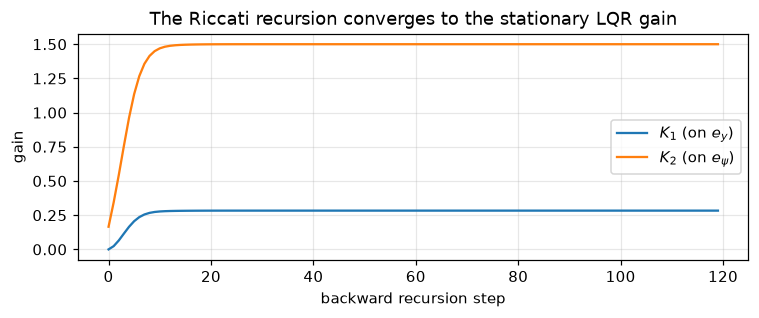

stationary gain K = [0.28335712 1.50012967]


In [1]:
import numpy as np, matplotlib.pyplot as plt
L, Ts, V, DMAX = 2.7, 0.05, 15.0, 0.6

def linear_model(v=V):
    return (np.array([[1., v*Ts],[0., 1.]]),
            np.array([[0.],[v*Ts/L]]),
            np.array([[0.],[-v*Ts]]))

A, B, E = linear_model()
Q = np.diag([1.0, 5.0]); R = np.array([[8.0]])

# backward Riccati recursion from a terminal cost P_N = Q
P = Q.copy(); gains = []
for _ in range(120):
    K = np.linalg.solve(R + B.T@P@B, B.T@P@A)
    gains.append(K.ravel().copy())
    P = Q + A.T@P@A - A.T@P@B@K
gains = np.array(gains)

plt.figure(figsize=(7, 3))
plt.plot(gains[:,0], label="$K_1$ (on $e_y$)")
plt.plot(gains[:,1], label="$K_2$ (on $e_\\psi$)")
plt.xlabel("backward recursion step"); plt.ylabel("gain")
plt.title("The Riccati recursion converges to the stationary LQR gain")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("stationary gain K =", gains[-1])

## 3. The discrete algebraic Riccati equation (DARE)

The stationary $P$ is the symmetric positive-semidefinite solution of

$$ \boxed{\;P = Q + A^\top P A - A^\top P B\,(R+B^\top P B)^{-1}B^\top P A\;}
   \qquad K=(R+B^\top P B)^{-1}B^\top P A. $$

**When does a good solution exist?** If $(A,B)$ is *stabilizable* and
$(A,Q^{1/2})$ is *detectable*, the DARE has a unique symmetric PSD solution $P$ for
which the closed loop $A-BK$ is **Schur stable** - all eigenvalues strictly inside
the unit circle [2,5]. Our $(A,B)$ is controllable (notebook 01) and
$Q=\mathrm{diag}(1,5)\succ 0$, so $(A,Q^{1/2})$ is trivially detectable; both
conditions hold.

**How real solvers do it.** Production code uses a numerically robust Schur /
generalized-eigenvalue method on the associated Hamiltonian pencil [8] (e.g.
`scipy.linalg.solve_discrete_are`). To keep the course dependency-free we iterate
the recursion to its fixed point and *verify* the result by checking the DARE
residual.

In [2]:
def dlqr(A, B, Q, R, iters=1000, tol=1e-14):
    P = Q.copy()
    for _ in range(iters):
        Pn = Q + A.T@P@A - A.T@P@B@np.linalg.solve(R + B.T@P@B, B.T@P@A)
        if np.max(np.abs(Pn - P)) < tol:
            P = Pn; break
        P = Pn
    K = np.linalg.solve(R + B.T@P@B, B.T@P@A)
    return K, P

K, P = dlqr(A, B, Q, R)
residual = Q + A.T@P@A - A.T@P@B@np.linalg.solve(R + B.T@P@B, B.T@P@A) - P
print("K =", K.ravel())
print("DARE residual (max abs entry) = %.2e   <- should be ~ machine zero" % np.max(np.abs(residual)))

K = [0.28335712 1.50012967]
DARE residual (max abs entry) = 7.11e-15   <- should be ~ machine zero


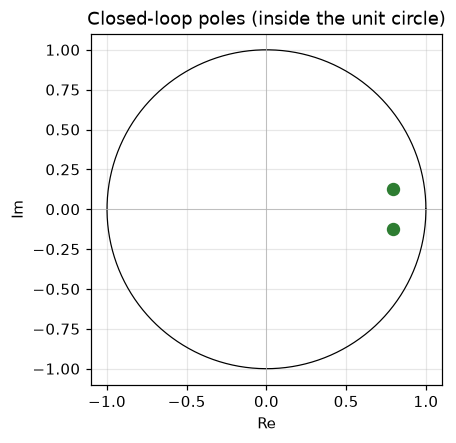

eigenvalues: [0.7916+0.125j 0.7916-0.125j]  spectral radius = 0.801


In [3]:
# Closed-loop stability: eigenvalues of (A - B K) must lie inside the unit circle
ev = np.linalg.eigvals(A - B@K)
th = np.linspace(0, 2*np.pi, 300)
plt.figure(figsize=(4.2, 4.2))
plt.plot(np.cos(th), np.sin(th), 'k', lw=.8)
plt.scatter(ev.real, ev.imag, s=60, color="#2e7d32", zorder=3)
plt.axhline(0, color=".7", lw=.5); plt.axvline(0, color=".7", lw=.5)
plt.gca().set_aspect("equal")
plt.title("Closed-loop poles (inside the unit circle)")
plt.xlabel("Re"); plt.ylabel("Im"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("eigenvalues:", np.round(ev, 4), " spectral radius = %.3f" % np.max(np.abs(ev)))

## 4. Choosing $Q$ and $R$

A practical starting point is **Bryson's rule** [4]: make each term of the cost
order-one by scaling with the largest acceptable value of each variable,

$$ Q_{ii}=\frac{1}{x_{i,\max}^2},\qquad R_{jj}=\frac{1}{\delta_{\max}^2}, $$

then tune by hand. Because only the *ratio* $Q/R$ matters, sweeping $R$ traces a
frontier between tracking accuracy and control effort - the fundamental LQR
tradeoff. Each point below is a fully re-solved controller simulated on the same
recovery manoeuvre.

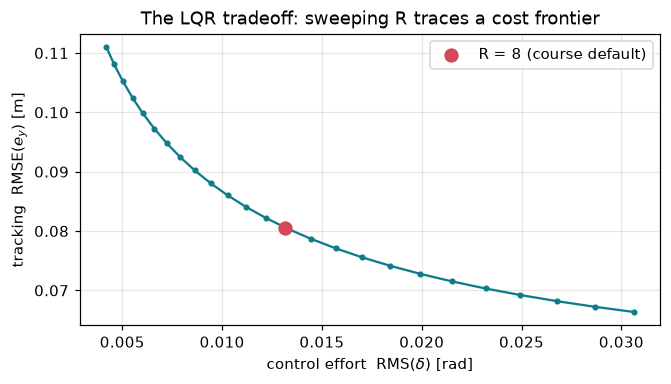

small R (aggressive): RMSE 0.066, effort 0.031
large R (gentle)    : RMSE 0.111, effort 0.004


In [4]:
def sim_recovery(K, kappa=0.0, x0=(0.5, 0.0), n=200, ff=False):
    x = np.array(x0, float); ey, du = [], []
    for _ in range(n):
        d = (np.arctan(L*kappa) if ff else 0.0) - float((K@x).ravel()[0])
        d = np.clip(d, -DMAX, DMAX); ey.append(x[0]); du.append(d)
        x = np.array([x[0] + V*np.sin(x[1])*Ts, x[1] + (V/L*np.tan(d) - V*kappa)*Ts])
    return np.sqrt(np.mean(np.square(ey))), np.sqrt(np.mean(np.square(du)))

Rs = np.geomspace(0.5, 200, 25)
pts = np.array([sim_recovery(dlqr(A, B, Q, np.array([[r]]))[0]) for r in Rs])
star = sim_recovery(dlqr(A, B, Q, np.array([[8.0]]))[0])

plt.figure(figsize=(6.2, 3.6))
plt.plot(pts[:,1], pts[:,0], '-o', ms=3, color="#0e7c8b")
plt.scatter(star[1], star[0], s=70, color="#d1495b", zorder=3, label="R = 8 (course default)")
plt.xlabel("control effort  RMS($\\delta$) [rad]")
plt.ylabel("tracking  RMSE($e_y$) [m]")
plt.title("The LQR tradeoff: sweeping R traces a cost frontier")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("small R (aggressive): RMSE %.3f, effort %.3f" % tuple(pts[0]))
print("large R (gentle)    : RMSE %.3f, effort %.3f" % tuple(pts[-1]))

## 5. Feed-forward: a two-degree-of-freedom controller

Pure feedback leaves a **steady-state error on a curve**, because holding a bend
needs a nonzero steering angle that error-driven feedback only supplies once an
error already exists. For a constant curvature $\kappa$ the linear closed loop
settles at

$$ x_{ss}=\big(I-(A-BK)\big)^{-1}E\,\kappa \;\neq\; 0. $$

We cancel it with a feed-forward term from the road geometry. Setting the
curvature contribution of $\dot e_\psi$ to zero,

$$ \frac{v}{L}\tan\delta_{ff}=v\,\kappa \;\Longrightarrow\; \delta_{ff}=\arctan(L\kappa), $$

and the command becomes $\delta=\delta_{ff}-Kx$. This is a **two-degree-of-freedom**
design: feedback shapes the transient and rejects disturbances, feed-forward
handles the known geometry. Because $\delta_{ff}$ comes from the map, not the
camera, it stays valid in the full system even when perception is untrusted and
authority shifts to the driver (notebook 07).

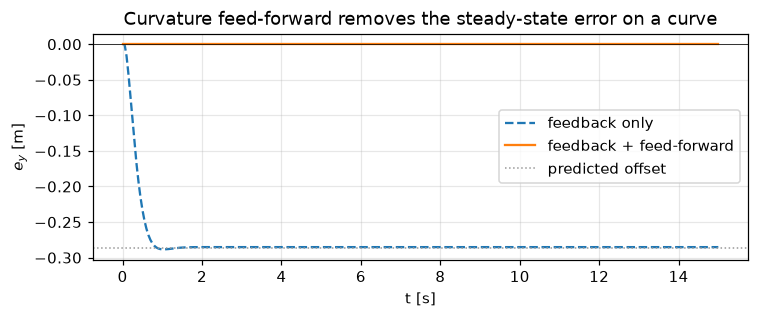

feedback only: predicted steady-state e_y = -0.286 m


In [5]:
kappa = 0.03
K, P = dlqr(A, B, Q, R)
x_ss = np.linalg.solve(np.eye(2) - (A - B@K), (E*kappa).ravel())
print("feedback only: predicted steady-state e_y = %.3f m" % x_ss[0])

def run(ff):
    x = np.array([0.0, 0.0]); H = [x]
    for _ in range(300):
        d = (np.arctan(L*kappa) if ff else 0.0) - float((K@x).ravel()[0])
        d = np.clip(d, -DMAX, DMAX)
        x = np.array([x[0] + V*np.sin(x[1])*Ts, x[1] + (V/L*np.tan(d) - V*kappa)*Ts]); H.append(x)
    return np.array(H)

t = np.arange(301)*Ts
plt.figure(figsize=(7, 3))
plt.plot(t, run(False)[:,0], '--', label="feedback only")
plt.plot(t, run(True)[:,0], label="feedback + feed-forward")
plt.axhline(0, color='k', lw=.5)
plt.axhline(x_ss[0], color='.6', ls=':', lw=1, label="predicted offset")
plt.xlabel("t [s]"); plt.ylabel("$e_y$ [m]")
plt.title("Curvature feed-forward removes the steady-state error on a curve")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. Gain scheduling: a linear-parameter-varying controller

$A$ and $B$ depend on the speed $v$, so a single gain is optimal only at one speed.
Since the integrity monitor will later *slow the car down* under low trust
(notebook 07), we recompute $K(v)$ per speed - a **gain-scheduled** or
linear-parameter-varying (LPV) controller [7], with $v$ as the scheduling
parameter. The scheduled design keeps the closed loop comfortably stable across
the whole operating range.

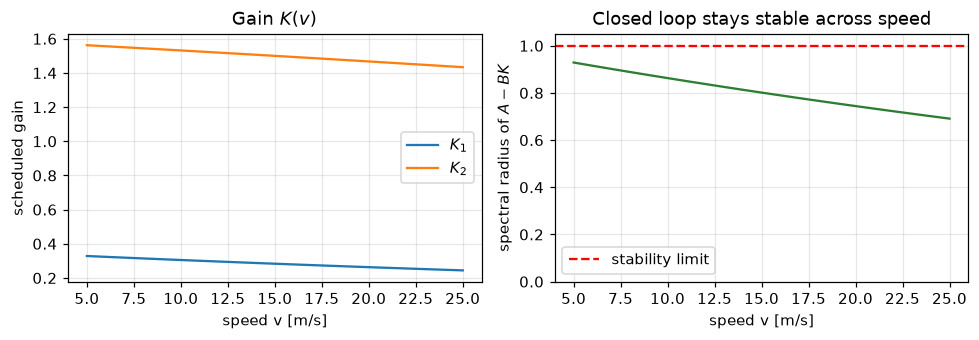

In [6]:
vs = np.linspace(5, 25, 21)
Kv, rho = [], []
for v in vs:
    Av, Bv, _ = linear_model(v)
    Kg = dlqr(Av, Bv, Q, R)[0]
    Kv.append(Kg.ravel()); rho.append(np.max(np.abs(np.linalg.eigvals(Av - Bv@Kg))))
Kv = np.array(Kv)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(vs, Kv[:,0], label="$K_1$"); ax[0].plot(vs, Kv[:,1], label="$K_2$")
ax[0].set(xlabel="speed v [m/s]", ylabel="scheduled gain", title="Gain $K(v)$")
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(vs, rho, color="#2e7d32"); ax[1].axhline(1, ls="--", color="r", label="stability limit")
ax[1].set(xlabel="speed v [m/s]", ylabel="spectral radius of $A-BK$",
          title="Closed loop stays stable across speed", ylim=(0, 1.05))
ax[1].legend(); ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()

## 7. Two classical facts worth knowing

**Robustness.** Full-state LQR is not only optimal, it is robust: the
continuous-time regulator has a guaranteed gain margin of $(\tfrac12,\infty)$ and a
phase margin of at least $60^\circ$ at each input, from the return-difference
inequality [2,6]. (The discrete-time picture is analogous; the clean margins are
the continuous-time result.) This is part of why LQR is such a strong baseline.

**We do not actually measure the state.** LQR assumes access to $x$. In the full
system the controller sees only the noisy perception estimate, so we pair LQR with
a state estimator - the Kalman filter of notebook 05. The **separation principle**
states that the optimal LQG controller is exactly the LQR gain applied to the
Kalman estimate, and the two may be designed independently [2].

### Exercises

1. Re-derive $K_k$ by setting the gradient of the Bellman right-hand side to zero.
   Where is convexity (hence a unique minimiser) used?
2. If `scipy` is available, replace the Riccati iteration with
   `scipy.linalg.solve_discrete_are` and confirm the gains match to machine precision.
3. Apply the gain designed at $v=15$ at $v=6$ (no rescheduling). Does the loop stay
   stable? Compare its poles to the scheduled design.
4. Use Bryson's rule with $e_{y,\max}=0.5$ m, $e_{\psi,\max}=0.1$ rad,
   $\delta_{\max}=0.2$ rad to choose $Q,R$; compare the resulting gain to the default.

## References

1. R. E. Kalman. *Contributions to the theory of optimal control.* Boletin de la Sociedad Matematica Mexicana, 5:102-119, 1960.
2. B. D. O. Anderson, J. B. Moore. *Optimal Control: Linear Quadratic Methods.* Prentice Hall, 1990.
3. D. P. Bertsekas. *Dynamic Programming and Optimal Control, Vol. I.* Athena Scientific, 2017.
4. A. E. Bryson, Y.-C. Ho. *Applied Optimal Control.* Hemisphere, 1975. (Bryson's rule for weight selection.)
5. P. Lancaster, L. Rodman. *Algebraic Riccati Equations.* Oxford University Press, 1995.
6. M. G. Safonov, M. Athans. *Gain and phase margin for multiloop LQG regulators.* IEEE Transactions on Automatic Control, 22(2):173-179, 1977. doi:10.1109/TAC.1977.1101251
7. W. J. Rugh, J. S. Shamma. *Research on gain scheduling.* Automatica, 36(10):1401-1425, 2000. doi:10.1016/S0005-1098(00)00058-3
8. A. J. Laub. *A Schur method for solving algebraic Riccati equations.* IEEE Transactions on Automatic Control, 24(6):913-921, 1979. doi:10.1109/TAC.1979.1102178
9. R. Rajamani. *Vehicle Dynamics and Control,* 2nd ed. Springer, 2012. (Lane-keeping error dynamics.)